In [70]:
import pandas as pd

In [71]:
df_train = pd.read_csv('../csv_files/cleaned_data/train_data_cleaned.csv')
df_test = pd.read_csv('../csv_files/cleaned_data/test_data_cleaned.csv')
df_test = pd.read_csv('../csv_files/cleaned_data/test_data_cleaned.csv')
df_test_dropped = pd.read_csv('../csv_files/cleaned_data/df_test_dropped.csv')


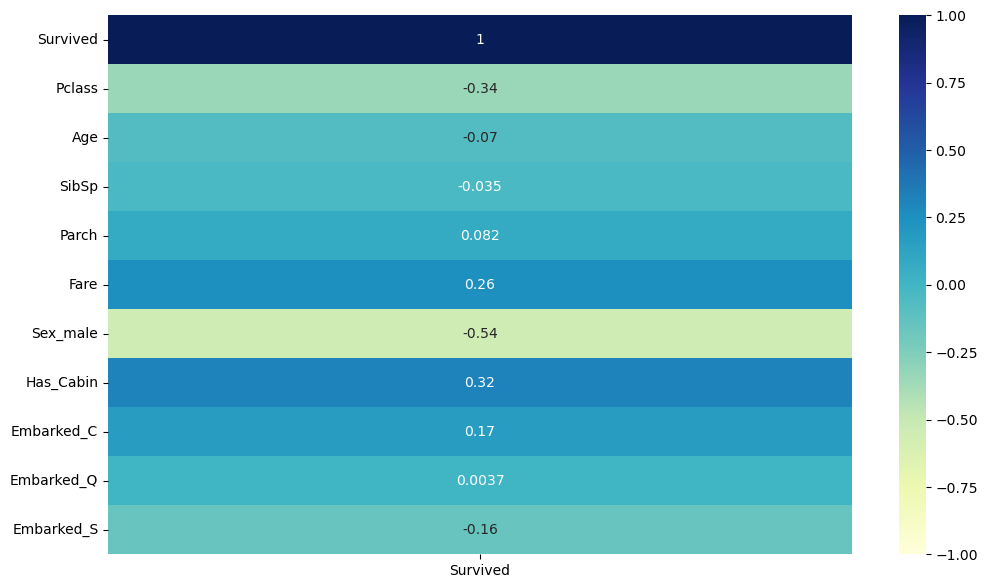

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_train.corr()
plt.figure(figsize=(12, 7))
corr_survived = corr_matrix[['Survived']]
sns.heatmap(corr_survived, annot=True, cmap="YlGnBu", vmin=-1, vmax=1)

plt.show()


In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split

X = df_train.drop('Survived', axis=1)  # Features
y = df_train['Survived']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

model_1 = LogisticRegression(random_state=1)

rfe = RFE(model_1, n_features_to_select=10)  

rfe.fit(X_train, y_train)

X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

model_1.fit(X_train_rfe, y_train)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

LogisticRegression(random_state=1)

In [74]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model_1.predict_proba(X_test_rfe)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

y_pred = model_1.predict(X_test_rfe)

auc = roc_auc_score(y_test, y_proba)

In [75]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [76]:
score = model_1.score(X_test_rfe,y_test)

print("auc: %.2f" % auc)
print("model score: %.2f" % score)

print(classification_report(y_test,y_pred))

auc: 0.83
model score: 0.81
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       106
           1       0.77      0.75      0.76        73

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [77]:
#Results from model 1: 
#The model is fairy accurate
#train models 2 and 3 with L1 and L2 regularixation in attempt to get better results

In [81]:
# Train L1 Regularization model now

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y, random_state=3, train_size=0.8)

model_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=1)
model_l1.fit(X_train, y_train)

y_pred_2 = model_l1.predict(X_test_2)
y_proba_2 = model_l1.predict_proba(X_test_2)[:, 1]

auc_l1 = roc_auc_score(y_test_2, y_proba_2)

print("auc: L1 %.2f" % auc_l1)
print("model score: %.2f" % model_l1.score(X_test_2, y_test_2))

print(classification_report(y_test_2, y_pred_2))

auc: L1 0.83
model score: 0.79
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       109
           1       0.72      0.74      0.73        70

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [82]:
# Train L2 Regularization model now

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X, y, random_state=3, train_size=0.8)


model_l2 = LogisticRegression(penalty='l2', random_state=4)
model_l2.fit(X_train_3, y_train_3)

y_pred_l2 = model_l2.predict(X_test_3)
y_proba_l2 = model_l2.predict_proba(X_test_3)[:, 1]


auc_l2 = roc_auc_score(y_test_3, y_proba_l2)

print("auc: L2 %.2f" % auc_l2)
print("model score: %.2f" % model_l2.score(X_test_3, y_test_3))

print(classification_report(y_test_3, y_pred_l2))

auc: L2 0.81
model score: 0.77
              precision    recall  f1-score   support

           0       0.82      0.79      0.80       109
           1       0.69      0.73      0.71        70

    accuracy                           0.77       179
   macro avg       0.75      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#Note, model 1 performed the best, try a decision tree for better results

In [78]:
from sklearn.tree import DecisionTreeClassifier

model_2 = DecisionTreeClassifier(max_depth=2, random_state=2)
model_2.fit(X_train_rfe,y_train)

DecisionTreeClassifier(max_depth=2, random_state=2)

In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_pred = model_2.predict(X_test_rfe)
y_proba = model_2.predict_proba(X_test_rfe)[:, 1]

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

print(classification_report(y_test,y_pred))

auc = roc_auc_score(y_test, y_proba)
print("auc: %.2f" % auc)


Confusion Matrix:
 [[99  7]
 [43 30]]
              precision    recall  f1-score   support

           0       0.70      0.93      0.80       106
           1       0.81      0.41      0.55        73

    accuracy                           0.72       179
   macro avg       0.75      0.67      0.67       179
weighted avg       0.74      0.72      0.70       179

auc: 0.77


In [101]:
# Prepare submission file with test data from best performing model: Model 1

prediction_1 = model_1.predict(df_test)

df_submission = pd.DataFrame({'PassengerId': df_test_dropped['PassengerId'],'Survived': prediction_1})

df_submission.to_csv('../csv_files/submissions/logRegression_submission_10_28_2024.csv', index=False)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
